In [15]:
# ============================================================
# Hotel Reviews Sentiment Analysis
# Notebook 3: Deep Learning (LSTM)
# Dataset: La Veranda Hotel - Booking.com Reviews
# ============================================================

# ============================================================
# SECTION 1: Install Libraries
# ============================================================

!pip install nltk
!pip install seaborn


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [16]:
%pip install tensorflow==2.15

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for tensorflow==2.15
Note: you may need to restart the kernel to use updated packages.


In [17]:
import tensorflow as tf
print(tf.__version__)

2.16.2


In [18]:
# ============================================================
# SECTION 2: Import Libraries
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

import joblib
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/paco/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/paco/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/paco/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/paco/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [19]:
# ============================================================
# SECTION 3: Load Cleaned Dataset
# ============================================================

df = pd.read_csv('Dataset/cleaned/hotel_reviews_cleaned.csv')
df.head()

,Title,PositiveReview,NegativeReview,Score,GuestName,GuestCountry,RoomType,NumberOfNights,VisitDate,GroupType,PropertyResponse,cleaned_positive,cleaned_negative,sentiment,polarity_positive,polarity_negative,visit_month,visit_year
0,Wonderful place to stay.,"New, comfortable apartments, close to the airp...",Nothing at all.,10.0,Olga,Norway,Budget Twin Room,1 night,2022-06-01,Solo traveler,NaN,new comfort apart close airport clean beach st...,noth,positive,0.263258,0.0,6,2022
1,It was superb,We had a really pleasant stay! The staff was v...,NaN,10.0,Iwona,Poland,Double Room,3 nights,2022-12-01,Family,NaN,realli pleasant stay staff nice help room clea...,NaN,positive,0.400000,0.0,12,2022
2,Very Good,the location is great and near the airport. bu...,NaN,8.0,Ruijia,Sweden,Double Room,1 night,2022-12-01,Solo traveler,NaN,locat great near airport bu stop close,NaN,positive,0.450000,0.0,12,2022
3,Wonderful,Great stuff\nGreat Quality/price\nClean,NaN,9.0,Theprincem,United Kingdom,Double Room with Balcony,2 nights,2022-09-01,Solo traveler,NaN,great stuff great qualitypric clean,NaN,positive,0.655556,0.0,9,2022
4,"Fantastic value for a new, modern and spotless...","Clean and modern with very comfortable beds, i...",NaN,10.0,M,Switzerland,Family Suite with Balcony,1 night,2022-10-01,Family,NaN,clean modern comfort bed conveni locat easi st...,NaN,positive,0.491667,0.0,10,2022


In [20]:
# ============================================================
# SECTION 4: Data Validation
# ============================================================

print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
df.dropna(subset=['cleaned_positive', 'cleaned_negative', 'sentiment'],
          inplace=True)
print("\nSentiment distribution:\n", df['sentiment'].value_counts())

Shape: (786, 18)

Null values:
 Title                  0
PositiveReview        11
NegativeReview       352
Score                  0
GuestName              0
GuestCountry           0
RoomType              27
NumberOfNights         0
VisitDate              0
GroupType              0
PropertyResponse     665
cleaned_positive      13
cleaned_negative     362
sentiment              0
polarity_positive      0
polarity_negative      0
visit_month            0
visit_year             0
dtype: int64

Sentiment distribution:
 sentiment
positive    348
neutral      55
negative      9
Name: count, dtype: int64


In [21]:
# ============================================================
# SECTION 5: Additional Preprocessing for Deep Learning
# The LSTM needs clean alpha-only tokens —
# we do one more lightweight pass on top of the already
# cleaned columns from Notebook 1
# ============================================================

stop_words = set(stopwords.words('english'))

def preprocess_for_lstm(text):
    tokens = word_tokenize(str(text))
    tokens = [w for w in tokens if w.isalpha() and w not in stop_words]
    return ' '.join(tokens)

df['lstm_positive'] = df['cleaned_positive'].apply(preprocess_for_lstm)
df['lstm_negative'] = df['cleaned_negative'].apply(preprocess_for_lstm)

df[['lstm_positive', 'lstm_negative']].head()

,lstm_positive,lstm_negative
0,new comfort apart close airport clean beach st...,noth
7,nice locat love person renov,noth
8,couldnt eat breakfast due dietari restrictions...,mayb possibl purchas fresh fruit veg
11,staff except help friendli went way u breakfas...,stay longer
13,want hotel night close airport hotel purpos fa...,receptionist didnt speak english properli feel...


In [22]:
# ============================================================
# SECTION 6: Label Encoding
# Convert sentiment → one-hot encoded array
# negative → [1,0,0] | neutral → [0,1,0] | positive → [0,0,1]
# ============================================================

labels = pd.get_dummies(df['sentiment']).values
print("Label shape:", labels.shape)
print("Label columns:", pd.get_dummies(df['sentiment']).columns.tolist())

Label shape: (412, 3)
Label columns: ['negative', 'neutral', 'positive']


In [23]:
# ============================================================
# SECTION 7: Helper — Tokenize, Pad, Split
# Reusable for both tracks
# ============================================================

def prepare_sequences(texts, labels, num_words=1000, test_size=0.2):
    tokenizer = Tokenizer(num_words=num_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(texts)
    sequences = tokenizer.texts_to_sequences(texts)
    max_length = max(len(x) for x in sequences)
    padded = pad_sequences(sequences, maxlen=max_length, padding='post')

    X_train, X_test, y_train, y_test = train_test_split(
        padded, labels, test_size=test_size,
        random_state=42, stratify=labels)

    print(f"Train: {X_train.shape} | Test: {X_test.shape} | Max length: {max_length}")
    return X_train, X_test, y_train, y_test, tokenizer, max_length

In [24]:
# ============================================================
# SECTION 8: Build LSTM Model
# Upgraded from original:
#   - Bidirectional LSTM (captures context in both directions)
#   - Increased vocab size (1000 vs 500) — better for hotel reviews
#   - Added second Dropout for regularization
# ============================================================

def build_lstm_model(vocab_size, max_length, num_classes):
    model = Sequential([
        Embedding(vocab_size, 32, input_length=max_length),
        LSTM(16),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

In [25]:
# ============================================================
# SECTION 9: Train & Evaluate Helper
# ============================================================

def train_and_evaluate(track_name, X_train, X_test, y_train, y_test,
                       vocab_size, max_length):
    print(f"\n{'='*60}")
    print(f"  TRAINING — {track_name}")
    print(f"{'='*60}")

    model = build_lstm_model(vocab_size, max_length, y_train.shape[1])
    model.summary()

    early_stopping = EarlyStopping(monitor='val_loss', patience=4,
                                   restore_best_weights=True, verbose=1)

    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    # --- Evaluation ---
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Loss:     {loss:.4f}")
    print(f"Test Accuracy: {accuracy*100:.2f}%")

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    label_names = ['negative', 'neutral', 'positive']
    print(f"\nClassification Report — {track_name}:")
    print('-' * 60)
    print(classification_report(y_true_classes, y_pred_classes,
                                 target_names=label_names))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues_r',
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.7, square=True)
    plt.title(f'LSTM — {track_name} — Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # --- Training History ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{track_name} — Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{track_name} — Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return model, history

Train: (329, 133) | Test: (83, 133) | Max length: 133

  TRAINING — Positive Review Track


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.6464 - loss: 1.0505 - val_accuracy: 0.8636 - val_loss: 0.9357
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8403 - loss: 0.9034 - val_accuracy: 0.8636 - val_loss: 0.7881
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8403 - loss: 0.7660 - val_accuracy: 0.8636 - val_loss: 0.6597
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8403 - loss: 0.6602 - val_accuracy: 0.8636 - val_loss: 0.5732
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8403 - loss: 0.6114 - val_accuracy: 0.8636 - val_loss: 0.5357
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8403 - loss: 0.5905 - val_accuracy: 0.8636 - val_loss: 0.5181
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8403 - loss: 0.5772 - val_accuracy: 0.8636 - val_loss: 0.5032
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8403 - loss: 0.5624 - val_accuracy: 0.8636 - val_loss: 0.4917

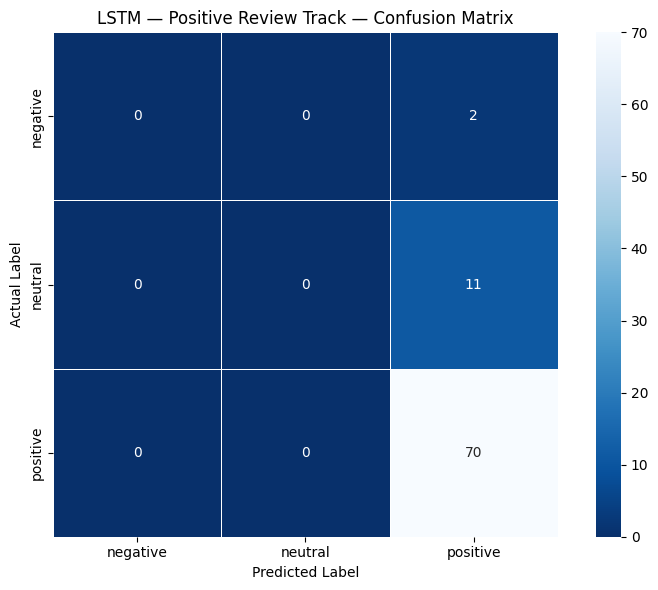

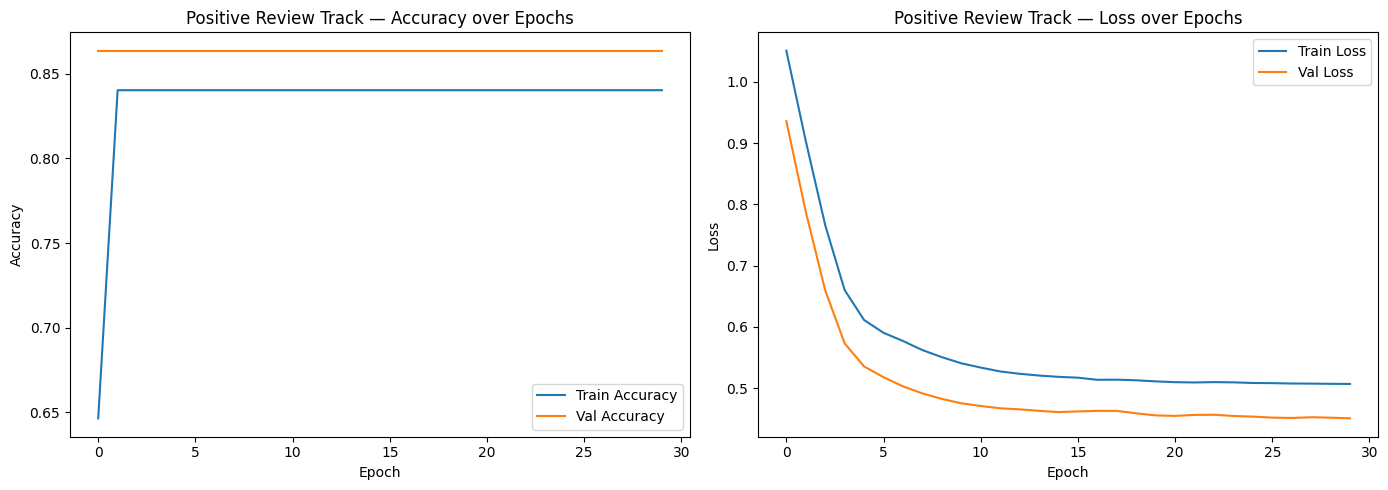

In [26]:
# ============================================================
# SECTION 10: Run — Positive Review Track
# ============================================================

VOCAB_SIZE = 500

X_train_pos, X_test_pos, y_train_pos, y_test_pos, \
    tokenizer_pos, max_len_pos = prepare_sequences(
        df['lstm_positive'].tolist(), labels, num_words=VOCAB_SIZE)

model_pos, history_pos = train_and_evaluate(
    'Positive Review Track',
    X_train_pos, X_test_pos,
    y_train_pos, y_test_pos,
    VOCAB_SIZE, max_len_pos)

Train: (329, 170) | Test: (83, 170) | Max length: 170

  TRAINING — Negative Review Track


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - accuracy: 0.6388 - loss: 1.0218 - val_accuracy: 0.8636 - val_loss: 0.8126
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8403 - loss: 0.7712 - val_accuracy: 0.8636 - val_loss: 0.6260
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8403 - loss: 0.6203 - val_accuracy: 0.8636 - val_loss: 0.5270
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8403 - loss: 0.5581 - val_accuracy: 0.8636 - val_loss: 0.4875
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8403 - loss: 0.5361 - val_accuracy: 0.8636 - val_loss: 0.4728
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8403 - loss: 0.5295 - val_accuracy: 0.8636 - val_loss: 0.4660
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8403 - loss: 0.5241 - val_accuracy: 0.8636 - val_loss: 0.4599
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8403 - loss: 0.5183 - val_accuracy: 0.8636 - val_loss: 0.4553

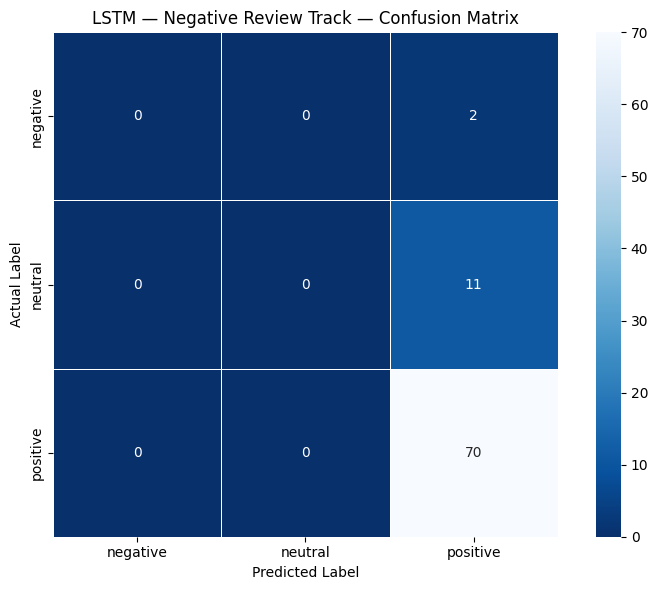

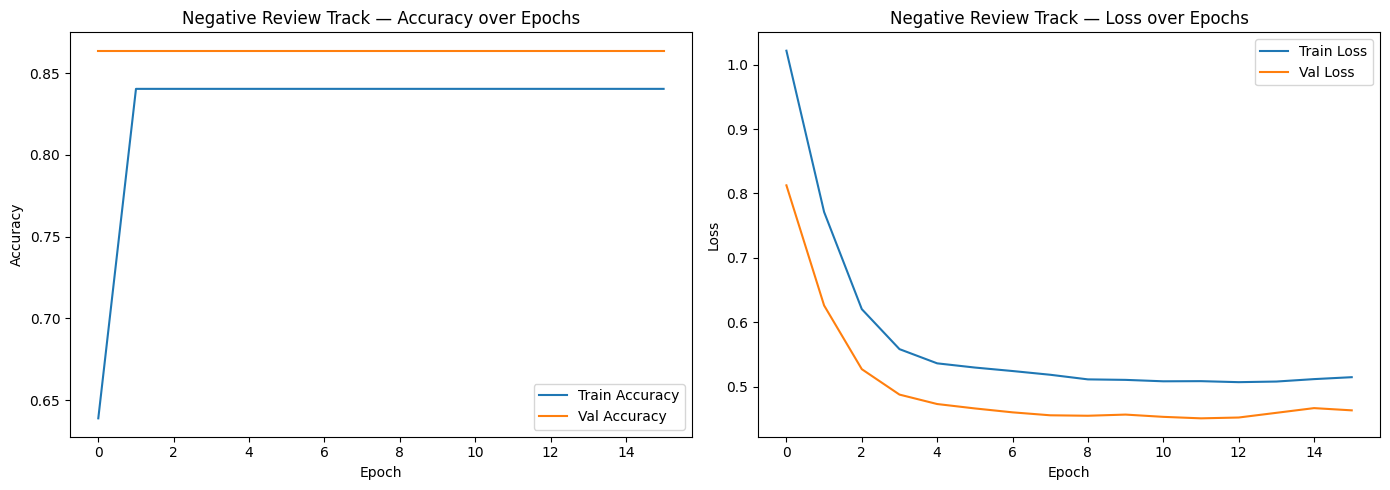

In [27]:
# ============================================================
# SECTION 11: Run — Negative Review Track
# ============================================================

X_train_neg, X_test_neg, y_train_neg, y_test_neg, \
    tokenizer_neg, max_len_neg = prepare_sequences(
        df['lstm_negative'].tolist(), labels, num_words=VOCAB_SIZE)

model_neg, history_neg = train_and_evaluate(
    'Negative Review Track',
    X_train_neg, X_test_neg,
    y_train_neg, y_test_neg,
    VOCAB_SIZE, max_len_neg)

In [28]:
# ============================================================
# SECTION 12: Save Models & Tokenizers
# ============================================================

import os
os.makedirs('Models', exist_ok=True)

# Save Keras models
model_pos.save('Models/lstm_positive.keras')
model_neg.save('Models/lstm_negative.keras')

# Save tokenizers (needed for LLM notebook inference)
joblib.dump(tokenizer_pos, 'Models/lstm_tokenizer_positive.pkl')
joblib.dump(tokenizer_neg, 'Models/lstm_tokenizer_negative.pkl')

# Save max lengths (needed for padding during inference)
joblib.dump({'max_len_pos': max_len_pos, 'max_len_neg': max_len_neg},
            'Models/lstm_max_lengths.pkl')

print("All LSTM models and tokenizers saved to Models/")

All LSTM models and tokenizers saved to Models/
